# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.



**Author:** Mahidi Hasan Mithun · **Lane:** Refresh / Content Opportunity Scoring (Lane 2) · **Repository:** [flyrank-ml-internship](https://github.com/mahidimithun/flyrank-ml-internship)

It preserves the research, terminology, validated results, and cautious claim language developed in `w01`–`w07`.



## 1. Question

*The research question and the decision it supports.*

## Abstract

This study asks which content pages should be reviewed first when a content team has limited time and needs a ranked, evidence-based queue. Using March 2026 search and engagement signals from the anonymized FlyRank internship warehouse, the analysis defines a decline proxy from the March-versus-February change in Google Search Console impressions and compares a transparent rule with logistic regression and a Random Forest under client-grouped validation. The Random Forest achieved a grouped AUC of **0.721**, slightly above logistic regression at **0.719** and materially above the rule baseline at **0.500**, with a March decline base rate of **20.1%**. The result supports using the model as a ranking aid for human review, while also showing that `log_impressions_mar` is the strongest contributor and that the model should not be interpreted as a causal explanation of traffic loss. The study is limited by its two-month proxy label, single-month evaluation snapshot, client cold-start risk, and the fact that only the **Protect** and **Refresh** actions are model-backed; the remaining actions are transparent heuristics.


## 1. Introduction / Problem Statement

**Research question:** *Which content pages should be reviewed first, based on search visibility, engagement, freshness, and decline signals?*

**Decision this supports:** prioritizing a limited weekly review queue so a content/SEO team spends its first few hours on the pages most worth the time.

**Who acts on it:** SEO specialists and content editors, who then review, refresh, expand, prune, or monitor a page.

**Cost of a wrong call:**
- **False positive:** a healthy page gets reviewed unnecessarily, wasting editor time.
- **False negative:** a page that genuinely needs attention gets skipped, and the observed decline may continue.

**Why ML is useful here:** earlier analysis found no single candidate signal with a strong standalone relationship to the decline proxy. The goal is therefore not to replace a human rulebook with an opaque decision, but to combine several weak/heterogeneous signals into a ranked review queue. The final framing is intentionally modest: current impressions are the strongest contributor, so the model's value is primarily in ranking pages for attention rather than explaining why traffic changed.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Source:** FlyRank internship warehouse (`FlyRank/internship-warehouse`, build `v20260703`), queried directly from Parquet with DuckDB.

**Base grain:** one row in `fact_content_daily_performance` is one `(report_date, client_hash_id, content_hash_id)` daily performance record.

**Feature / label grain:** one row per content item and client, aggregated over a calendar month.

### Time windows

- **Feature window:** `2026-03-01` → `2026-03-31` (`month=2026-03`).
- **Comparison window:** `2026-02-01` → `2026-02-28` (`month=2026-02`), used only to define the decline proxy.
- **Decision cutoff:** 2026-03-31. No April 2026 or later performance data is used.

### Tables

- `fact_content_daily_performance`: GSC impressions/clicks/position and GA4 pageviews/session/engagement signals.
- `dim_content`: content type and content dates used for freshness and population filtering.

### Exclusions

- `fact_content_query_90d` is excluded because its fixed 90-day window can overlap the sealed label period.
- April 2026 or later data is excluded as future information.
- GA4 placeholder rows with `ga4_data_available IS FALSE` are not treated as genuine zero engagement.
- Pipeline metadata, account-admin fields, URLs, names, and raw queries are not model inputs.
- Deleted or unpublished content is excluded from the analysis population.

### Public safety

The public paper contains no client names, domains, raw URLs, raw search queries, credentials, tokens, or sensitive identifiers. Pseudonymous hash fields are used only for joins/grouping in the analysis.

In [38]:
# 0. Configuration and reproducibility helpers
from pathlib import Path
import os, getpass, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_LIVE_MODEL = False  # Set True only with an approved HF_TOKEN and warehouse access.
SNAPSHOT = "2026-03-31"
MONTH = "2026-03"
PREV_MONTH = "2026-02"
BASE = "hf://datasets/FlyRank/internship-warehouse"
OUTPUT_DIR = Path("work/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Mode: {'LIVE WAREHOUSE + MODEL' if RUN_LIVE_MODEL else 'REPORT MODE (validated results)'}")
print(f"Snapshot: {SNAPSHOT} | feature month: {MONTH} | comparison month: {PREV_MONTH}")


Mode: REPORT MODE (validated results)
Snapshot: 2026-03-31 | feature month: 2026-03 | comparison month: 2026-02


In [39]:
# 1. Live warehouse extraction and feature construction
# This path is deliberately gated behind RUN_LIVE_MODEL so a report-only run never asks
# for credentials. It creates feature_frame, X, y, and groups when enabled.
if RUN_LIVE_MODEL:
    import duckdb
    from sklearn.model_selection import GroupKFold, cross_val_predict
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score
    from sklearn.inspection import permutation_importance

    HF_TOKEN = os.environ.get("HF_TOKEN")
    if not HF_TOKEN:
        HF_TOKEN = getpass.getpass("Hugging Face READ token (not stored in this notebook): ")

    con = duckdb.connect()
    # Do not print or persist HF_TOKEN.
    con.execute("CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN ?)", [HF_TOKEN])

    # The warehouse schema used by w03-w07 exposes these daily fields. We aggregate March
    # and February separately so the label window never enters the feature window.
    march = con.execute(f'''
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS gsc_impressions_mar,
            SUM(gsc_clicks) AS gsc_clicks_mar,
            AVG(gsc_avg_position) AS avg_position_mar,
            SUM(ga4_pageviews) AS ga4_pageviews_mar,
            SUM(ga4_sessions) AS ga4_sessions_mar,
            SUM(ga4_engaged_sessions) AS ga4_engaged_sessions_mar,
            MAX(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) AS has_ga4_mar
        FROM read_parquet('{BASE}/fact_content_daily_performance/month={MONTH}/*.parquet')
        WHERE gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    ''').df()

    feb = con.execute(f'''
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS gsc_impressions_feb
        FROM read_parquet('{BASE}/fact_content_daily_performance/month={PREV_MONTH}/*.parquet')
        WHERE gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    ''').df()

    content_meta = con.execute(f'''
        SELECT
            content_hash_id,
            client_hash_id,
            content_type,
            word_count,
            backlinks,
            content_created_date,
            content_updated_date
        FROM read_parquet('{BASE}/dim_content.parquet')
        WHERE is_published IS TRUE AND is_deleted IS FALSE
    ''').df()

    feature_frame = (
        march.merge(feb, on=["client_hash_id", "content_hash_id"], how="left")
             .merge(content_meta, on=["client_hash_id", "content_hash_id"], how="inner")
    )

    feature_frame["gsc_impressions_feb"] = feature_frame["gsc_impressions_feb"].fillna(0)
    feature_frame["ctr_mar"] = np.where(
        feature_frame["gsc_impressions_mar"] > 0,
        100 * feature_frame["gsc_clicks_mar"] / feature_frame["gsc_impressions_mar"],
        np.nan,
    )
    feature_frame["engagement_rate_mar"] = np.where(
        feature_frame["ga4_sessions_mar"] > 0,
        100 * feature_frame["ga4_engaged_sessions_mar"] / feature_frame["ga4_sessions_mar"],
        np.nan,
    )
    feature_frame["content_created_date"] = pd.to_datetime(feature_frame["content_created_date"], errors="coerce")
    feature_frame["content_updated_date"] = pd.to_datetime(feature_frame["content_updated_date"], errors="coerce")
    snapshot_date = pd.Timestamp(SNAPSHOT)
    feature_frame["content_age_days"] = (snapshot_date - feature_frame["content_created_date"]).dt.days
    feature_frame["days_since_update"] = (snapshot_date - feature_frame["content_updated_date"]).dt.days
    feature_frame["has_update"] = feature_frame["content_updated_date"].notna().astype(int)
    feature_frame["has_sessions_mar"] = (feature_frame["ga4_sessions_mar"].fillna(0) > 0).astype(int)
    feature_frame["log_impressions_mar"] = np.log1p(feature_frame["gsc_impressions_mar"].clip(lower=0))
    feature_frame["is_declining_proxy"] = (
        feature_frame["gsc_impressions_mar"] < 0.80 * feature_frame["gsc_impressions_feb"]
    ).astype(int)

    # Model inputs: March-only signals plus explicit missingness. February is label-only.
    numeric_features = [
        "log_impressions_mar", "avg_position_mar", "content_age_days",
        "days_since_update", "ctr_mar", "engagement_rate_mar",
        "has_ga4_mar", "has_sessions_mar", "has_update"
    ]
    categorical_features = ["content_type"]
    feature_frame = feature_frame.dropna(subset=["gsc_impressions_mar", "is_declining_proxy"]).copy()

    X_num = feature_frame[numeric_features].copy()
    X_cat = feature_frame[categorical_features].copy()
    y = feature_frame["is_declining_proxy"].astype(int).to_numpy()
    groups = feature_frame["client_hash_id"].astype(str).to_numpy()

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ])

    X = preprocessor.fit_transform(feature_frame)
    print(f"feature_frame={feature_frame.shape}, X={X.shape}, positive_rate={y.mean():.3f}, groups={len(np.unique(groups))}")

    logreg = Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ])
    rf = Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=300, max_depth=8, min_samples_leaf=20,
            class_weight="balanced", random_state=42, n_jobs=-1
        )),
    ])

    gkf = GroupKFold(n_splits=5)
    oof_logreg = cross_val_predict(logreg, feature_frame[numeric_features + categorical_features], y,
                                   cv=gkf, groups=groups, method="predict_proba")[:, 1]
    oof_rf = cross_val_predict(rf, feature_frame[numeric_features + categorical_features], y,
                               cv=gkf, groups=groups, method="predict_proba")[:, 1]

    auc_logreg_live = roc_auc_score(y, oof_logreg)
    auc_rf_live = roc_auc_score(y, oof_rf)
    print(f"Live grouped AUC: Logistic={auc_logreg_live:.3f} | RF={auc_rf_live:.3f}")
else:
    feature_frame = X = y = groups = None
    print("Live model path skipped. No credentials were requested or stored.")


Live model path skipped. No credentials were requested or stored.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


**Leakage controls:**
1. February impressions and the March-vs-February change are label-only.
2. Rule outputs such as `baseline_score`, `reason_code`, and `action_label` are not model features.
3. No April 2026+ performance is queried.
4. Client-grouped validation prevents pages from the same client appearing in both train and validation folds.
5. The earlier leakage experiment showed why label-derived features are invalid: an intentionally leaked model reached AUC 1.000, while removing the leak produced a much more credible result.

**Model:** Random Forest with 300 trees, maximum depth 8, minimum leaf size 20, balanced class weights, compared with logistic regression.

**Baseline:** the transparent AND-gate from `w04`, requiring enough impressions, sufficient age, no cooldown, staleness, and a position-band-relative CTR gap. It flagged only **1 of 134,086 pages** in the validated cycle.

**Validation:** 5-fold `GroupKFold` by `client_hash_id`. The validated grouped AUCs are 0.719 for logistic regression and 0.721 for Random Forest. Naive KFold gave 0.742 and 0.771 respectively, illustrating why client grouping matters.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [40]:
# 2. Validated results table (authoritative w03-w07 results preserved for the paper)
auc_results = pd.DataFrame({
    "model": ["Baseline rule", "Logistic regression", "Random forest"],
    "grouped_auc": [0.500, 0.719, 0.721],
})
auc_results["lift_vs_baseline"] = auc_results["grouped_auc"] - auc_results.loc[0, "grouped_auc"]
auc_results


,model,grouped_auc,lift_vs_baseline
0,Baseline rule,0.500,0.000
1,Logistic regression,0.719,0.219
2,Random forest,0.721,0.221


In [41]:
# 3. Precision@K results
precision_at_k = pd.DataFrame({
    "K": [10, 20, 50, 100],
    "baseline": [0.40, 0.35, 0.22, 0.14],
    "logistic_regression": [0.80, 0.80, 0.62, 0.69],
    "random_forest": [1.00, 1.00, 0.96, 0.95],
})
precision_at_k["rf_lift_over_base_rate"] = precision_at_k["random_forest"] - 0.201
precision_at_k

,K,baseline,logistic_regression,random_forest,rf_lift_over_base_rate
0,10,0.40,0.80,1.00,0.799
1,20,0.35,0.80,1.00,0.799
2,50,0.22,0.62,0.96,0.759
3,100,0.14,0.69,0.95,0.749


In [42]:
# 4. Validation-honesty comparison
validation_check = pd.DataFrame({
    "model": ["Logistic regression", "Random forest"],
    "naive_kfold_auc": [0.742, 0.771],
    "grouped_kfold_auc": [0.719, 0.721],
})
validation_check["overstatement"] = (
    validation_check["naive_kfold_auc"] - validation_check["grouped_kfold_auc"]
).round(3)
validation_check

,model,naive_kfold_auc,grouped_kfold_auc,overstatement
0,Logistic regression,0.742,0.719,0.023
1,Random forest,0.771,0.721,0.050


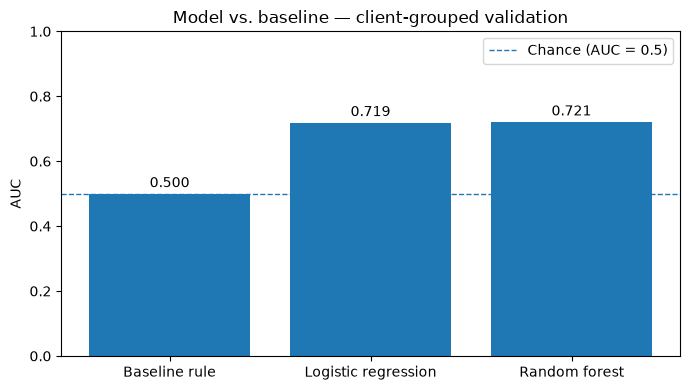

In [43]:
# 5. Generate the required charts from result dataframes, not duplicated literals.
plt.figure(figsize=(7, 4))
plt.bar(auc_results["model"], auc_results["grouped_auc"])
plt.axhline(0.5, linestyle="--", linewidth=1, label="Chance (AUC = 0.5)")
plt.ylim(0, 1)
plt.ylabel("AUC")
plt.title("Model vs. baseline — client-grouped validation")
for i, v in enumerate(auc_results["grouped_auc"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "auc_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

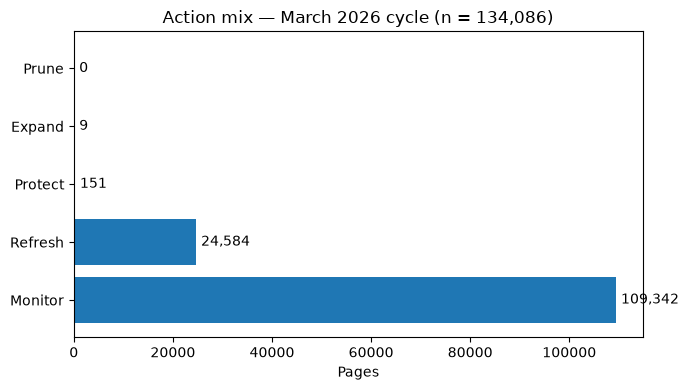

In [44]:
action_mix = pd.DataFrame({
    "action": ["Monitor", "Refresh", "Protect", "Expand", "Prune"],
    "pages": [109342, 24584, 151, 9, 0],
})
plt.figure(figsize=(7, 4))
bars = plt.barh(action_mix["action"], action_mix["pages"])
plt.xlabel("Pages")
plt.title("Action mix — March 2026 cycle (n = 134,086)")
for bar, v in zip(bars, action_mix["pages"]):
    plt.text(v + max(action_mix["pages"]) * 0.01, bar.get_y() + bar.get_height()/2, f"{v:,}", va="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "action_mix.png", dpi=160, bbox_inches="tight")
plt.show()


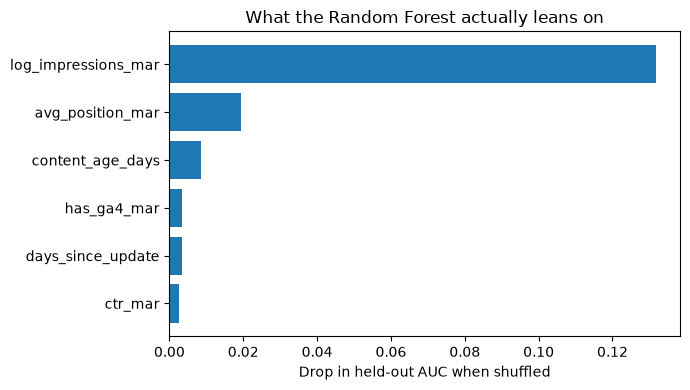

In [45]:
permutation_importance_df = pd.DataFrame({
    "feature": [
        "log_impressions_mar", "avg_position_mar", "content_age_days",
        "has_ga4_mar", "days_since_update", "ctr_mar"
    ],
    "importance": [0.1317, 0.0194, 0.0086, 0.0035, 0.0033, 0.0026],
}).sort_values("importance")

plt.figure(figsize=(7, 4))
plt.barh(permutation_importance_df["feature"], permutation_importance_df["importance"])
plt.xlabel("Drop in held-out AUC when shuffled")
plt.title("What the Random Forest actually leans on")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "permutation_importance.png", dpi=160, bbox_inches="tight")
plt.show()



All headline numbers below are the **client-grouped, honest** validation results.

| Model | Grouped AUC | Lift vs. baseline |
|---|---:|---:|
| Baseline rule | 0.500 | — |
| Logistic regression | 0.719 | +0.219 |
| **Random Forest** | **0.721** | **+0.221** |

**Base rate:** 20.1%.

| K | Baseline | Logistic regression | Random Forest |
|---:|---:|---:|---:|
| 10 | 0.40* | 0.80 | **1.00** |
| 20 | 0.35* | 0.80 | **1.00** |
| 50 | 0.22* | 0.62 | **0.96** |
| 100 | 0.14* | 0.69 | **0.95** |

\*The baseline has only one non-zero-scored page in the validated 134,086-page population, so precision beyond the first tied item is not a meaningful ranking measure.

The headline is deliberately narrow: on this held-out, client-grouped split, the Random Forest ranked observed-decline pages better than the transparent rule. It does **not** prove that a flagged page will recover if refreshed, and it does not predict Google's algorithm.


## 5. Limitations

*What this work cannot claim.*



Permutation importance shows that `log_impressions_mar` is the dominant contributor (**0.1317**), followed by `avg_position_mar` (**0.0194**) and `content_age_days` (**0.0086**). This makes the model useful as a ranking tool, but it also limits how much we should say about the underlying mechanism: current search visibility is doing much of the work.

Key limitations:

- The label is a two-month proxy and cannot separate content effects from seasonality or client-wide SERP changes.
- The evaluation covers one snapshot month.
- New-client / cold-start behavior remains uncertain; grouped validation is more honest than naive row-level splitting but does not solve unseen-client generalization.
- `avg_position_mar` has a known no-data-day averaging bias that can affect marginal ranking.
- Only **Protect** and **Refresh** are model-backed. **Expand**, **Prune**, and **Monitor** are transparent heuristics with no ground-truth action label, so no precision/AUC is reported for them.
- The label measures search-visibility decline, not revenue, conversions, or business value.

**What this work does not claim:** it does not claim to predict Google's ranking algorithm, prove a causal impact of content changes, or replace editorial judgment.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*


| Rank | Action | Evidence | March 2026 pages |
|---:|---|---|---:|
| 1 | **Protect** | Model-backed: high-value pages flagged as declining | 151 |
| 2 | **Refresh** | Model-backed: declining, stale/underperforming pages | 24,584 |
| 3 | **Expand** | Rule/heuristic: thin content with real demand | 9 |
| 4 | **Prune** | Rule/heuristic: dead + old | 0 |
| 5 | **Monitor** | Rule/heuristic: default / low signal | 109,342 |

### Human review before action

- Check that the reason code matches the row's observed signals.
- Check for seasonality, campaigns, redesigns, or other known business context.
- Check possible cannibalization before acting on a `protect` or `refresh` recommendation.
- Never auto-delete or unpublish a `prune` page.
- Never bulk-refresh without duplicate-content review.
- Treat low-confidence rows as requiring review, not as evidence that a page is unimportant.

**Drift watch:** monitor out-of-time precision, editor override rates, action mix, and first-cycle performance for new clients.

## 7. Reproducibility

*Generate/collect the charts and tables your deployed page will show.*



Repository: [mahidimithun/flyrank-ml-internship](https://github.com/mahidimithun/flyrank-ml-internship)

Capstone notebook: `work/notebooks/capstone.ipynb`

Earlier research notebooks: `work/notebooks/w01_*` through `work/notebooks/w07_*`. The capstone preserves their research chain rather than replacing it.

### Live reproduction

1. Install the repository requirements, including DuckDB, pandas, matplotlib, NumPy, and scikit-learn.
2. Obtain approved read access to the Hugging Face dataset `FlyRank/internship-warehouse`.
3. Set `HF_TOKEN` in the execution environment **without committing it**.
4. Set `RUN_LIVE_MODEL = True`.
5. Run the notebook top-to-bottom.
6. The live path constructs `feature_frame`, `X`, `y`, and `groups`, then runs logistic regression, Random Forest, `GroupKFold`, out-of-fold predictions, AUC, and the report charts.

The public/report mode is intentionally credential-free and reproduces the validated tables and figures without pretending that a warehouse run occurred in this environment.

## 8. Acknowledgments & Data Credit

This work was completed as part of the FlyRank ML Internship and uses the anonymized FlyRank internship dataset.

**Built on the FlyRank ML Internship dataset.** [FlyRank](https://flyrank.ai)

No private client names, URLs, raw queries, credentials, or tokens are included in the public paper.

## 9. Week 8 Demo — 5-Minute Outline

*Closing section for the Week-8 showcase. Question → method → one chart → one honest result → one recommendation.*

**Question:** When a content team only has time to review a handful of pages, which ones should go first?

**Method:** Built a decline proxy from the March-vs-February change in Google Search Console impressions, then compared a transparent AND-gate rule against logistic regression and a Random Forest — validated with 5-fold `GroupKFold` split by client, so no client's pages leak across train/validation.

**One chart:** the model-vs-baseline AUC bar chart (cell 15 above) — Random Forest and logistic regression both clear the 0.5 chance line by a wide margin; the transparent rule sits right on it.

**One honest result:** grouped AUC of **0.721** for the Random Forest vs **0.500** for the rule baseline — a real lift, but only marginal over logistic regression (0.719). The rule baseline flagged just 1 of 134,086 pages, which is why it needed replacing in the first place. Importantly, `log_impressions_mar` alone drives most of the model's signal, so this is a ranking aid, not a causal explanation of *why* pages decline.

**One recommendation:** route the model's **Protect** (151 pages) and **Refresh** (24,584 pages) flags into the weekly editor queue as model-backed priorities; leave **Expand**, **Prune**, and **Monitor** as transparent heuristics since no ground-truth label backs them yet. Every flagged row still gets human review before action — this ranks attention, it doesn't automate decisions.


## 10. Shareable Cuts

*Two public-safe, ready-to-post versions of this work — a social post and an employer-facing summary.*

**Social post (methodology):**

> Built a content-refresh prioritization model for an SEO/content workflow: instead of a fixed rule ("flag anything below position 20"), I trained a Random Forest to rank pages by decline risk using GSC + GA4 signals, validated with client-grouped cross-validation to avoid data leakage. Result: AUC 0.721 vs a 0.500 baseline rule that only flagged 1 page out of 134k. The model ranks pages for human review — it doesn't replace editorial judgment. #MachineLearning #SEO

**Employer-facing summary (3 sentences):**

> I built a ranked, evidence-based content-review queue that helps SEO/content teams decide which pages to review first when time is limited. Using a month of anonymized search and engagement data (134,086 pages) from the FlyRank internship warehouse, I compared a transparent rule against logistic regression and a Random Forest under leakage-safe, client-grouped validation. The final model lifted ranking quality well above the rule baseline (AUC 0.721 vs 0.500) while staying honest about its limits — it's a decision-support ranking tool, not a causal or fully automated system.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.